C:\Users\user12\AppData\Local\Temp\ipykernel_5892\3800798339.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["class"] = train_df["class"].apply(lambda x: 1 if x != 'normal' else 0)
C:\Users\user12\AppData\Local\Temp\ipykernel_5892\3800798339.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["class"] = test_df["class"].apply(lambda x: 1 if x != 'normal' else 0)


Epoch 1/10


c:\Users\user12\Anaconda3\envs\vivek\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3150/3150 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9666 - loss: 0.1086 - val_accuracy: 0.9910 - val_loss: 0.0274
Epoch 2/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9927 - loss: 0.0207 - val_accuracy: 0.9907 - val_loss: 0.0249
Epoch 3/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9941 - loss: 0.0172 - val_accuracy: 0.9929 - val_loss: 0.0224
Epoch 4/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9939 - loss: 0.0169 - val_accuracy: 0.9936 - val_loss: 0.0216
Epoch 5/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9948 - loss: 0.0147 - val_accuracy: 0.9943 - val_loss: 0.0204
Epoch 6/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9955 - loss: 0.0129 - val_accuracy: 0.9938 - val_loss: 0.0201
Epoch 7/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9957 - loss: 0.0131 - val_accuracy: 0.9944 - val_loss: 0.0186
Epoch 8/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9957 - loss: 0.0120 - val_accurac

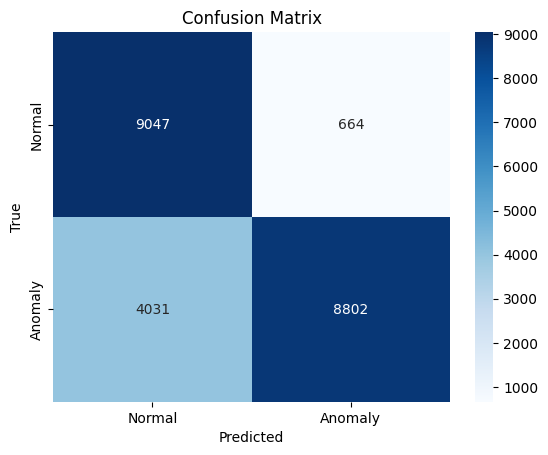

705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 588us/step


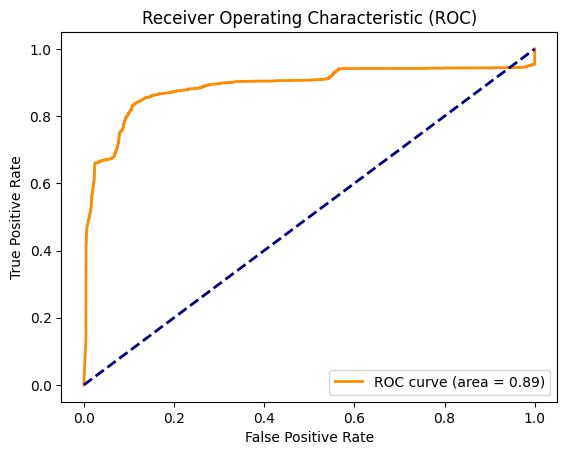

705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 588us/step


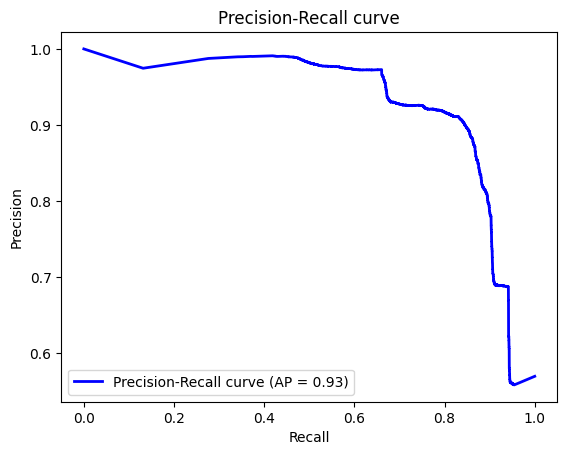

In [9]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load the dataset
def load_data():
    # Load the data
    train_df = pd.read_csv('KDDTrain+.txt', header=None)
    test_df = pd.read_csv('KDDTest+.txt', header=None)

    # Column names based on NSL-KDD dataset structure
    columns = [
        "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", 
        "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in", 
        "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations", 
        "num_shells", "num_access_files", "num_outbound_cmds", "is_hot_login", "is_guest_login", 
        "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate", 
        "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", 
        "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate", 
        "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate", 
        "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", 
        "class", "drop"
    ]
    
    train_df.columns = columns
    test_df.columns = columns

    # Remove the 'drop' column (as it is unnecessary for model)
    train_df = train_df.drop(columns=['drop'], errors='ignore')
    test_df = test_df.drop(columns=['drop'], errors='ignore')

    # Encode categorical features (protocol_type, service, flag)
    # Perform one-hot encoding on both training and testing data simultaneously to ensure consistent columns
    all_data = pd.concat([train_df, test_df], axis=0, ignore_index=True)
    all_data = pd.get_dummies(all_data, columns=["protocol_type", "service", "flag"])

    # After encoding, split the data back into train and test
    train_df = all_data.iloc[:len(train_df), :]
    test_df = all_data.iloc[len(train_df):, :]

    # Map 'class' column to binary labels: 'normal' -> 0, 'anomaly' -> 1
    train_df["class"] = train_df["class"].apply(lambda x: 1 if x != 'normal' else 0)
    test_df["class"] = test_df["class"].apply(lambda x: 1 if x != 'normal' else 0)

    # Separate features and labels
    X_train = train_df.drop(columns="class")
    y_train = train_df["class"]
    X_test = test_df.drop(columns="class")
    y_test = test_df["class"]

    # Standardize features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test

# Load the data
X_train, X_test, y_train, y_test = load_data()

# Split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Reshape data to fit RNN input shape (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Build RNN model
model = Sequential()
model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32)

# Evaluate the model on test data
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, model.predict(X_test))
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

# Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, model.predict(X_test))
avg_precision = average_precision_score(y_test, model.predict(X_test))
plt.figure()
plt.plot(recall_vals, precision_vals, color='blue', lw=2, label=f"Precision-Recall curve (AP = {avg_precision:.2f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.legend(loc='lower left')
plt.show()
